# 02 · Exploratory data analysis
Dataset: `data/student_dataset.csv` (**synthetic** — see notebook 01). All figures are also saved to
`outputs/figures/eda_*.png`.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src.utils import (FIG_DIR, PALETTE, CATEGORY_COLORS, ACADEMIC_LABELS, READINESS_LABELS,
                       NUMERIC_FEATURES, FEATURE_LABELS)
from src.preprocessing import load_raw, clean_dataset, detect_outliers_iqr
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
FIG_DIR.mkdir(parents=True, exist_ok=True)
def save(fig, name): fig.savefig(FIG_DIR / f"eda_{name}.png", dpi=130, bbox_inches="tight")
raw = load_raw()

## 1. Dataset dimensions and data types

In [2]:
print(f'Rows: {raw.shape[0]}  Columns: {raw.shape[1]}')
raw.dtypes.to_frame('dtype')

Rows: 1215  Columns: 20


,dtype
student_id,str
age,int64
gender,str
cgpa,float64
attendance_pct,float64
backlogs,int64
coding_score,float64
aptitude_score,int64
communication_score,float64
projects,int64


## 2. Missing-value analysis

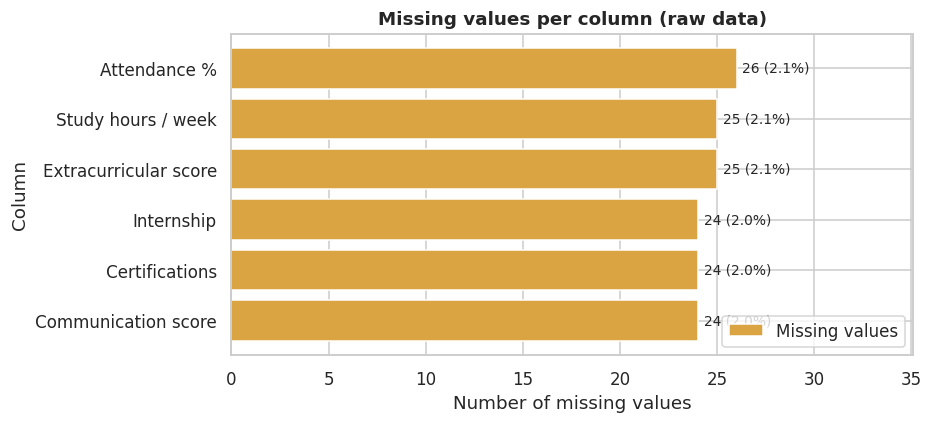

Duplicate rows: 15


In [3]:
miss = raw.isna().sum().loc[lambda s: s > 0].sort_values()
fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.barh([FEATURE_LABELS.get(c, c) for c in miss.index], miss.values, color=PALETTE["mustard"], label="Missing values")
for b, v in zip(bars, miss.values):
    ax.text(v + 0.3, b.get_y() + b.get_height()/2, f"{v} ({v/len(raw):.1%})", va="center", fontsize=9)
ax.set_title("Missing values per column (raw data)"); ax.set_xlabel("Number of missing values"); ax.set_ylabel("Column")
ax.set_xlim(0, miss.max() * 1.35); ax.legend(loc="lower right"); save(fig, "missing_values"); plt.show()
print('Duplicate rows:', raw.duplicated().sum())

## 3. Cleaning (rule-based, before the split) and outlier detection

In [4]:
df, report = clean_dataset(raw)
df['academic_performance'] = pd.Categorical(df['academic_performance'], ACADEMIC_LABELS, ordered=True)
df['placement_readiness'] = pd.Categorical(df['placement_readiness'], READINESS_LABELS, ordered=True)

rows_in                         : 1215
duplicates_removed              : 15
rows_missing_target_removed     : 0
impossible_values_set_to_nan    : {'cgpa': 2, 'attendance_pct': 2, 'coding_score': 1, 'study_hours_per_week': 1}
missing_values_after_cleaning   : {'cgpa': 2, 'attendance_pct': 26, 'coding_score': 1, 'communication_score': 24, 'certifications': 24, 'internship': 24, 'extracurricular_score': 24, 'study_hours_per_week': 25}
rows_out                        : 1200


In [5]:
out = detect_outliers_iqr(df)
out[["feature", "lower_fence", "upper_fence", "n_outliers", "pct_outliers"]].round(2)

,feature,lower_fence,upper_fence,n_outliers,pct_outliers
0,cgpa,4.49,9.4,15,1.25
1,attendance_pct,53.40,103.8,3,0.26
2,backlogs,-1.50,2.5,103,8.58
3,coding_score,11.50,103.5,3,0.25
4,aptitude_score,23.00,95.0,17,1.42
5,communication_score,30.50,98.5,7,0.60
6,projects,-2.00,6.0,19,1.58
7,certifications,-3.00,5.0,28,2.38
8,extracurricular_score,18.00,98.0,14,1.19
9,technical_skills_score,2.00,90.0,8,0.67


Values outside the *valid domain* (CGPA > 10, attendance > 100 %, negative scores) are data-entry errors and were set
to NaN (imputed later inside the training pipeline). IQR outliers **inside** the valid domain (e.g. 8 backlogs,
9 projects) are genuine students, so they are kept.

## 4. Descriptive statistics

In [6]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,1200.0,20.94,1.15,19.0,20.00,21.00,22.00,24.0
cgpa,1198.0,6.94,0.97,4.0,6.33,6.96,7.56,10.0
attendance_pct,1174.0,78.52,9.47,48.5,72.30,78.60,84.90,100.0
backlogs,1200.0,0.77,1.56,0.0,0.00,0.00,1.00,10.0
coding_score,1199.0,57.32,16.42,5.0,46.00,57.00,69.00,100.0
aptitude_score,1200.0,59.29,14.14,10.0,50.00,59.00,68.00,100.0
communication_score,1176.0,64.01,12.71,21.0,56.00,64.00,73.00,100.0
projects,1200.0,1.79,1.66,0.0,1.00,1.00,3.00,10.0
certifications,1176.0,1.61,1.57,0.0,0.00,1.00,2.00,9.0
extracurricular_score,1176.0,57.94,15.34,12.0,48.00,57.00,68.00,100.0


## 5. Correlation matrix

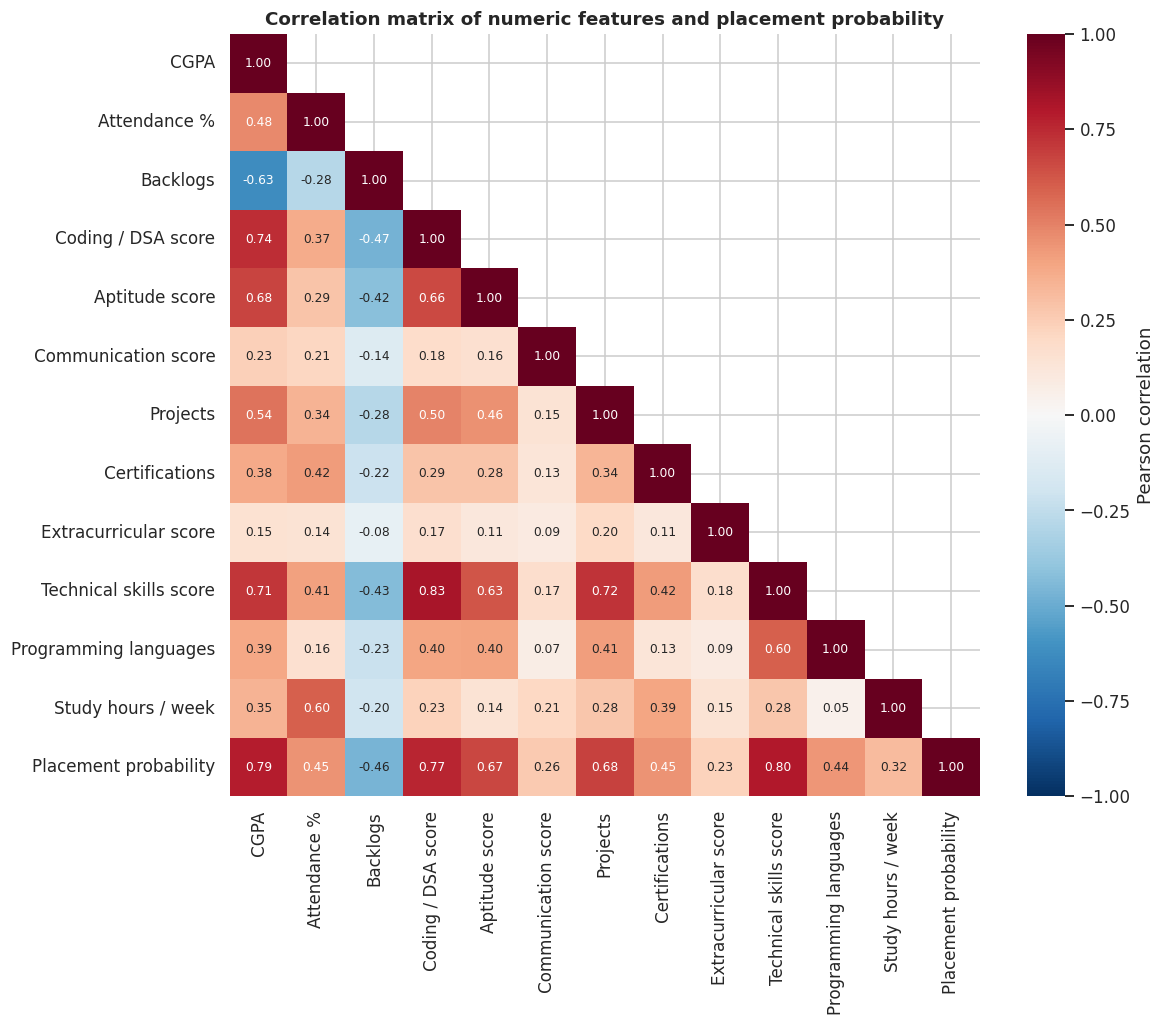

Technical skills score    0.797
CGPA                      0.787
Coding / DSA score        0.765
Projects                  0.683
Aptitude score            0.667
Attendance %              0.451
Certifications            0.449
Programming languages     0.438
Study hours / week        0.320
Communication score       0.260
Extracurricular score     0.233
Backlogs                 -0.461
Name: Placement probability, dtype: float64

In [7]:
num = df[NUMERIC_FEATURES + ["placement_probability"]].rename(columns=FEATURE_LABELS | {"placement_probability": "Placement probability"})
corr = num.corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot_kws={"fontsize": 8}, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Correlation matrix of numeric features and placement probability")
save(fig, "correlation_matrix"); plt.show()
corr["Placement probability"].drop("Placement probability").sort_values(ascending=False).round(3)

## 6. Univariate distributions

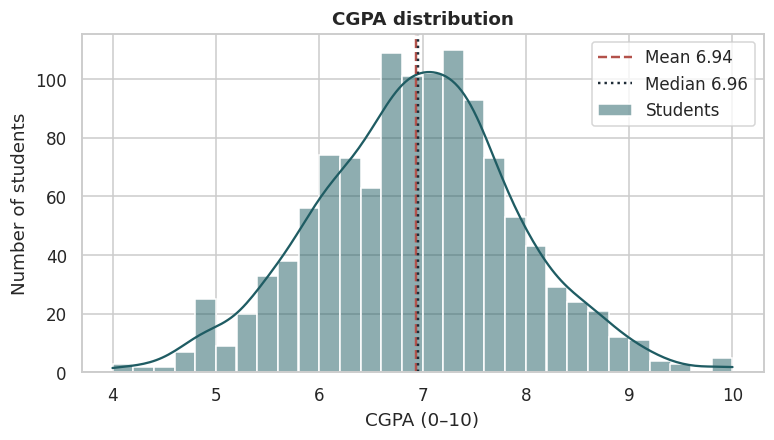

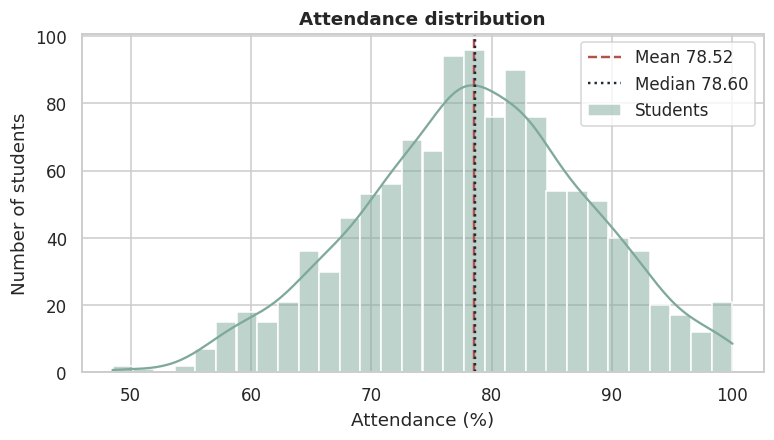

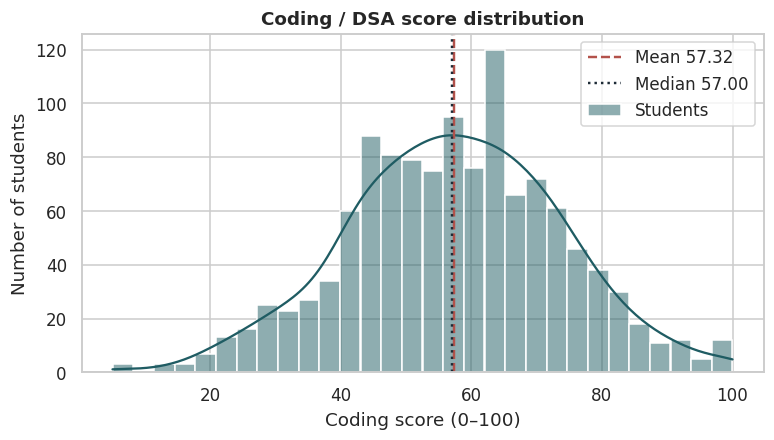

In [8]:
def hist(col, title, xlabel, bins=30, color=PALETTE["teal"]):
    s = df[col].dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(s, bins=bins, kde=True, color=color, ax=ax, label="Students")
    ax.axvline(s.mean(), color=PALETTE["brick"], ls="--", lw=1.6, label=f"Mean {s.mean():.2f}")
    ax.axvline(s.median(), color=PALETTE["ink"], ls=":", lw=1.6, label=f"Median {s.median():.2f}")
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("Number of students"); ax.legend()
    save(fig, col); plt.show()
hist("cgpa", "CGPA distribution", "CGPA (0–10)")
hist("attendance_pct", "Attendance distribution", "Attendance (%)", color=PALETTE["sage"])
hist("coding_score", "Coding / DSA score distribution", "Coding score (0–100)", color=PALETTE["teal"])

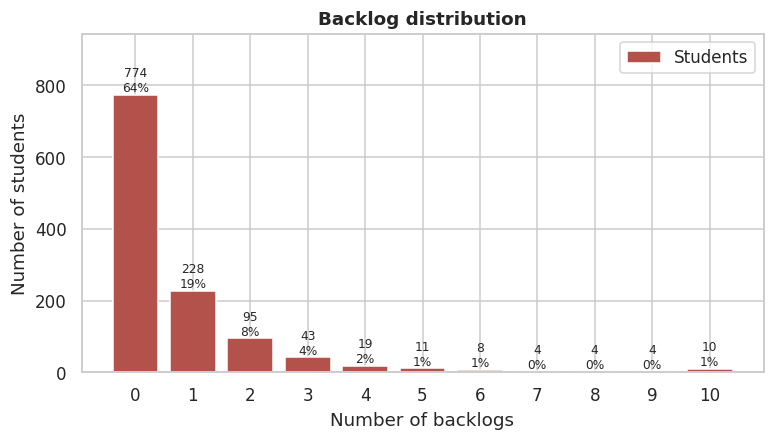

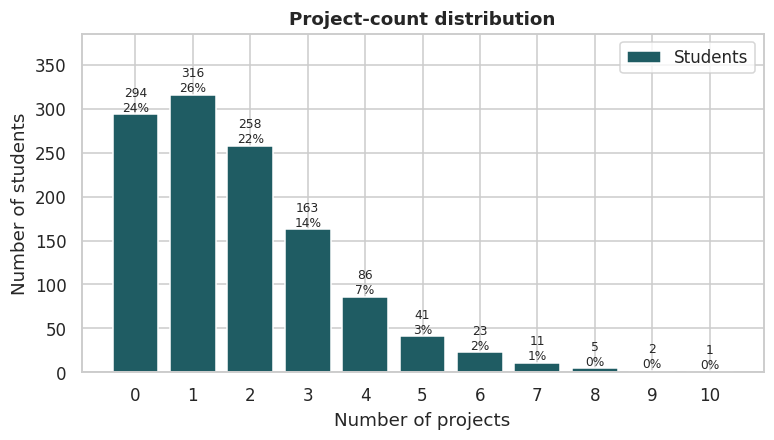

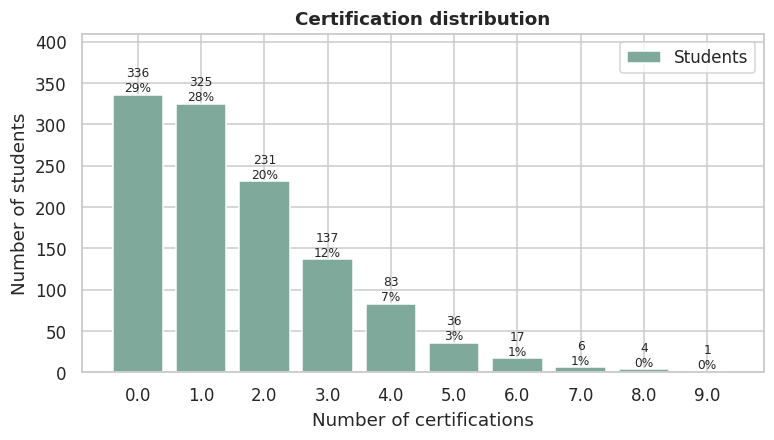

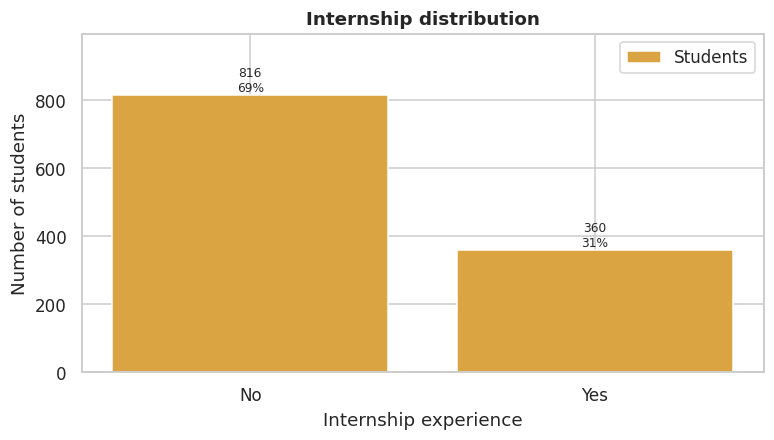

In [9]:
def countplot(col, title, xlabel, color=PALETTE["teal"], order=None):
    s = df[col].dropna()
    counts = s.value_counts().sort_index() if order is None else s.value_counts().reindex(order)
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(counts.index.astype(str), counts.values, color=color, label="Students")
    for b, v in zip(bars, counts.values):
        ax.annotate(f"{v}\n{v/counts.sum():.0%}", (b.get_x() + b.get_width()/2, v), ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, counts.max() * 1.22)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("Number of students"); ax.legend()
    save(fig, col); plt.show()
countplot("backlogs", "Backlog distribution", "Number of backlogs", PALETTE["brick"])
countplot("projects", "Project-count distribution", "Number of projects")
countplot("certifications", "Certification distribution", "Number of certifications", PALETTE["sage"])
countplot("internship", "Internship distribution", "Internship experience", PALETTE["mustard"], order=["No", "Yes"])

## 7. Target distributions

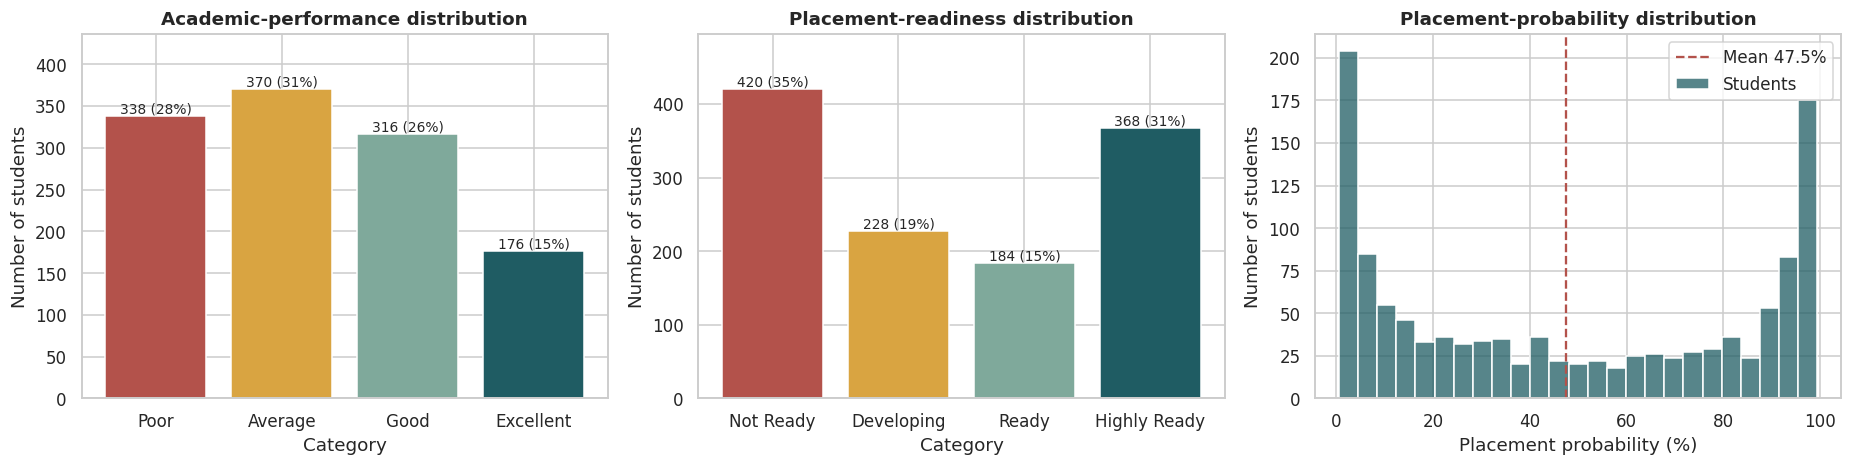

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
for ax, col, labels, title in [(axes[0], "academic_performance", ACADEMIC_LABELS, "Academic-performance distribution"),
                               (axes[1], "placement_readiness", READINESS_LABELS, "Placement-readiness distribution")]:
    counts = df[col].value_counts().reindex(labels)
    bars = ax.bar(labels, counts.values, color=[CATEGORY_COLORS[l] for l in labels])
    for b, v in zip(bars, counts.values):
        ax.annotate(f"{v} ({v/counts.sum():.0%})", (b.get_x()+b.get_width()/2, v), ha="center", va="bottom", fontsize=9)
    ax.set_title(title); ax.set_xlabel("Category"); ax.set_ylabel("Number of students"); ax.set_ylim(0, counts.max()*1.18)
sns.histplot(df["placement_probability"], bins=25, color=PALETTE["teal"], ax=axes[2], label="Students")
axes[2].axvline(df["placement_probability"].mean(), color=PALETTE["brick"], ls="--", label=f"Mean {df['placement_probability'].mean():.1f}%")
axes[2].set_title("Placement-probability distribution"); axes[2].set_xlabel("Placement probability (%)"); axes[2].set_ylabel("Number of students"); axes[2].legend()
fig.tight_layout(); save(fig, "targets"); plt.show()

Classes are imbalanced (e.g. only ~15 % *Excellent*), so models are compared with **macro-F1**, which weights every class equally, rather than accuracy alone.

## 8. Relationships with the targets

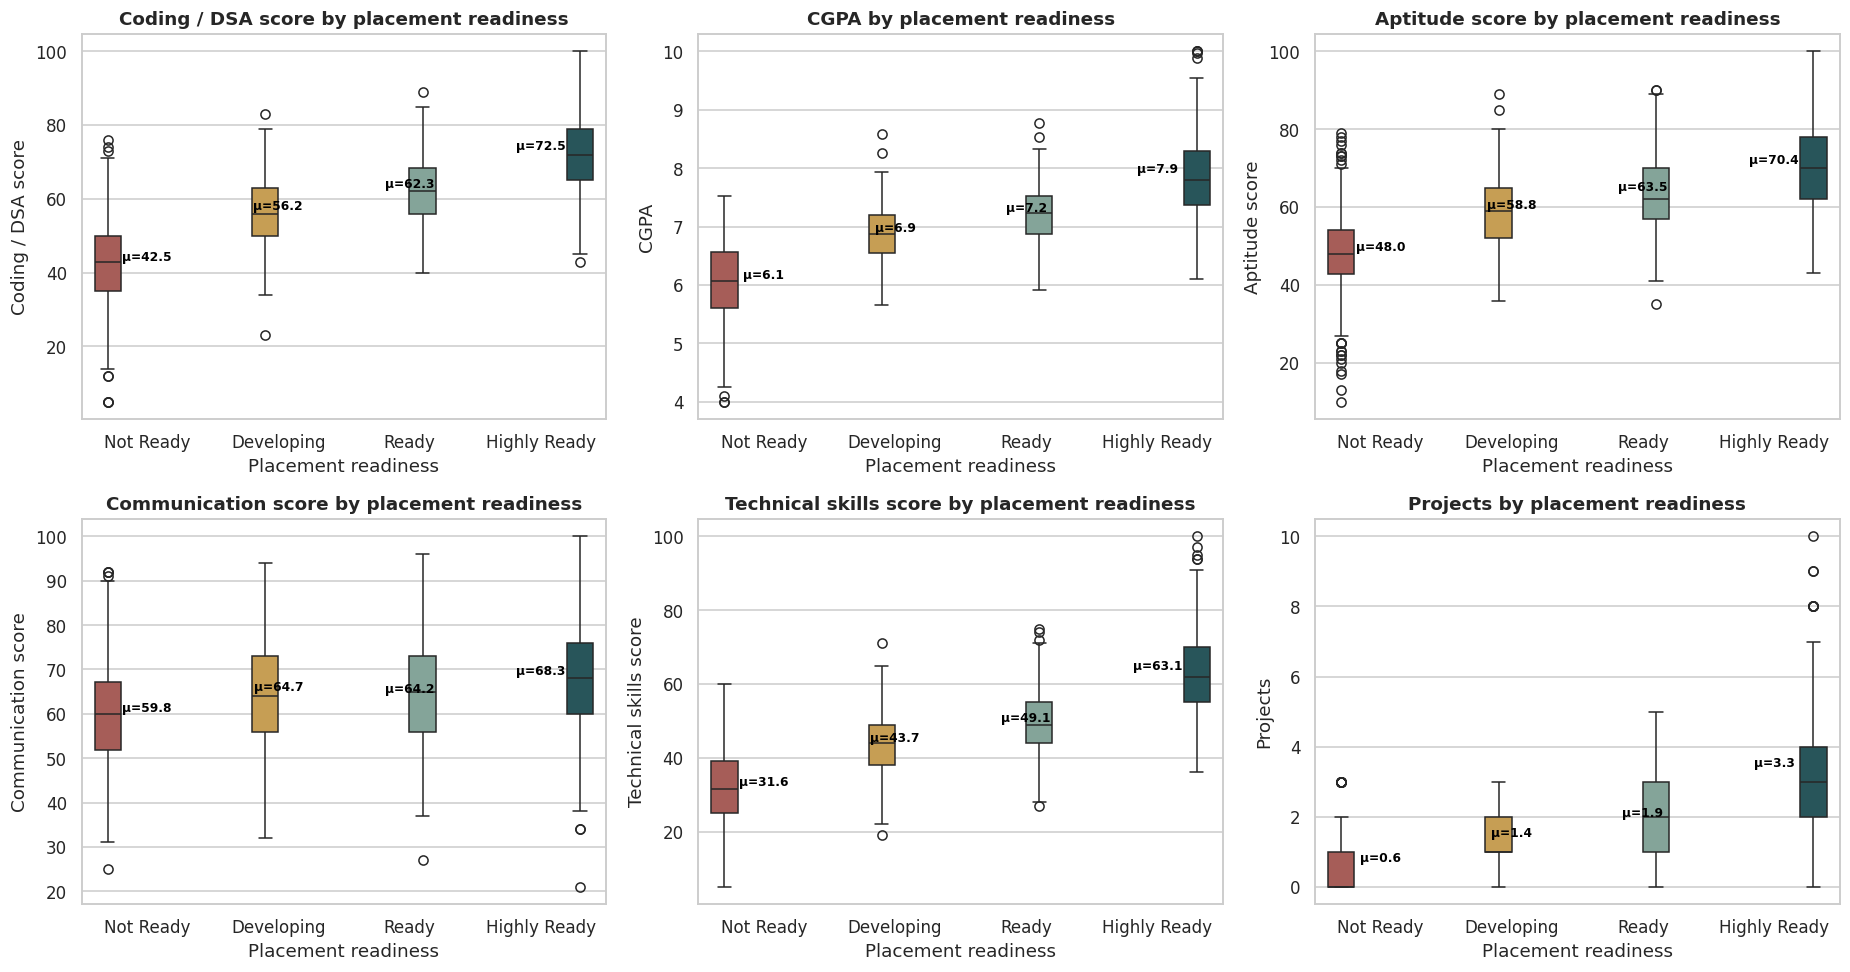

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
pal = {l: CATEGORY_COLORS[l] for l in READINESS_LABELS}
for ax, col in zip(axes.flat, ["coding_score", "cgpa", "aptitude_score", "communication_score", "technical_skills_score", "projects"]):
    sns.boxplot(data=df, x="placement_readiness", y=col, hue="placement_readiness", palette=pal, legend=False, ax=ax)
    means = df.groupby("placement_readiness", observed=True)[col].mean()
    for i, m in enumerate(means): ax.text(i, m, f"μ={m:.1f}", ha="center", va="bottom", fontsize=8, color="black", fontweight="bold")
    ax.set_title(f"{FEATURE_LABELS[col]} by placement readiness"); ax.set_xlabel("Placement readiness"); ax.set_ylabel(FEATURE_LABELS[col])
fig.tight_layout(); save(fig, "features_by_readiness"); plt.show()

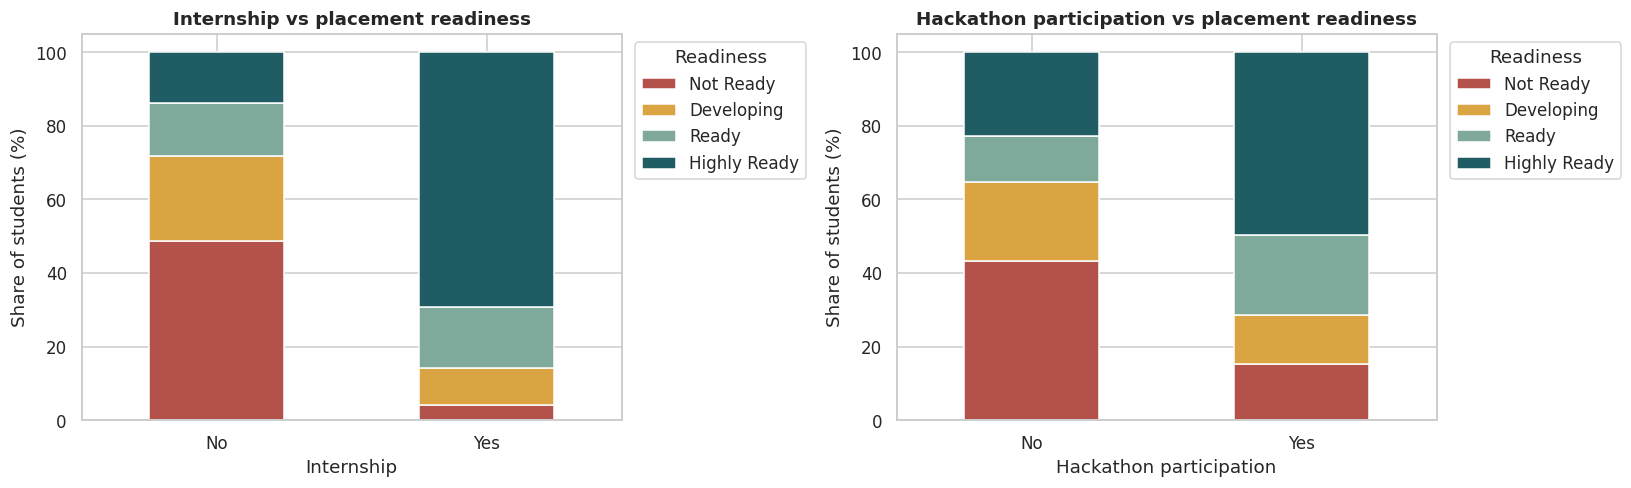

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
for ax, col in zip(axes, ["internship", "hackathon"]):
    ct = pd.crosstab(df[col], df["placement_readiness"], normalize="index").reindex(["No", "Yes"]) * 100
    ct.plot(kind="bar", stacked=True, color=[CATEGORY_COLORS[l] for l in READINESS_LABELS], ax=ax, rot=0)
    ax.set_title(f"{FEATURE_LABELS[col]} vs placement readiness"); ax.set_xlabel(FEATURE_LABELS[col]); ax.set_ylabel("Share of students (%)")
    ax.legend(title="Readiness", bbox_to_anchor=(1.01, 1), loc="upper left")
fig.tight_layout(); save(fig, "experience_vs_readiness"); plt.show()

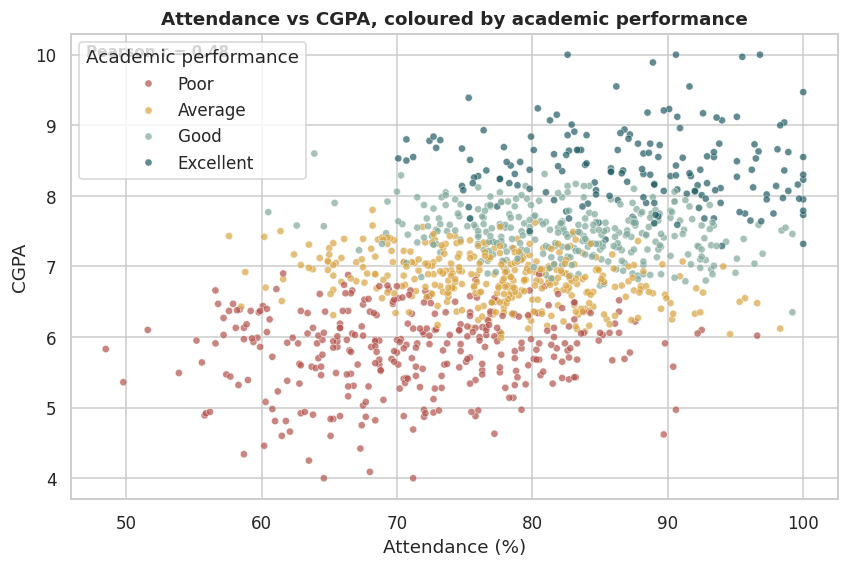

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=df, x="attendance_pct", y="cgpa", hue="academic_performance",
                palette={l: CATEGORY_COLORS[l] for l in ACADEMIC_LABELS}, alpha=0.7, s=22, ax=ax)
r = df[["attendance_pct", "cgpa"]].corr().iloc[0, 1]
ax.text(0.02, 0.95, f"Pearson r = {r:.2f}", transform=ax.transAxes, fontsize=10, fontweight="bold")
ax.set_title("Attendance vs CGPA, coloured by academic performance"); ax.set_xlabel("Attendance (%)"); ax.set_ylabel("CGPA")
ax.legend(title="Academic performance"); save(fig, "attendance_vs_cgpa"); plt.show()

## 9. Demographic check
Gender is excluded from modelling; here we confirm the synthetic outcomes do not differ systematically by gender.

In [14]:
df.groupby('gender')[['cgpa','coding_score','placement_probability']].agg(['mean','count']).round(2)

cgpa       coding_score       placement_probability      
        mean count         mean count                  mean count
gender                                                           
Female  6.90   462        56.39   461                 45.99   462
Male    6.96   712        57.87   714                 48.42   714
Other   7.07    24        59.04    24                 46.70    24

## Key findings
- CGPA, coding score, technical skills and aptitude correlate most strongly with placement probability; backlogs correlate negatively.
- Students with an internship are much more often *Ready / Highly Ready* — by design of the synthetic generator.
- Attendance and CGPA are positively correlated (shared "diligence" trait).
- Missing values are few (~2 % per affected column) and are handled by median / most-frequent imputation inside the pipeline.
- Remember: these patterns were **built into** the synthetic generator; EDA confirms the data behaves as designed,
  it does not discover facts about real students.